In [1]:
%load_ext autoreload
%autoreload 2
%xmode verbose

Exception reporting mode: Verbose


In [2]:
import pandas
import matplotlib.pyplot as plot
import numpy

data = pandas.read_csv('all_exoplanet_data.csv')
data['radius'] = data['pl_rade']
data['mass'] = data['pl_bmasse']
data = data[['radius', 'mass']].dropna().reset_index(drop = True)
data = data.sort_values('radius').reset_index(drop = True)
data = data.reset_index(drop = True)
data.min(), data.max()

/var/folders/jc/h35mhndj30l_xk52p_1lqvxh0000gn/T/ipykernel_2493/3922626628.py:5: DtypeWarning: Columns (35,50) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pandas.read_csv('all_exoplanet_data.csv')


(radius    0.29631
 mass      0.06500
 dtype: float64,
 radius       77.3421
 mass      25426.4000
 dtype: float64)

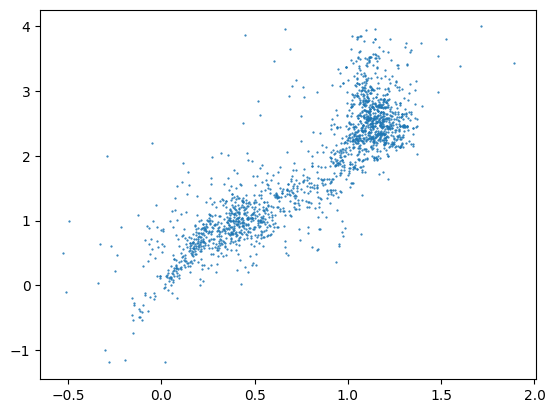

In [3]:
x = data['radius']
y = data['mass']

x = numpy.log10(x)
y = numpy.log10(y)

_, unique_indices = numpy.unique(x, return_index = True)
x, y = x[unique_indices], y[unique_indices]

# mask = (-0.25 < x) & (x < 1.5)
# x, y = x[mask], y[mask]

plot.scatter(x, y, s = 0.3)
# plot.loglog()
plot.show()

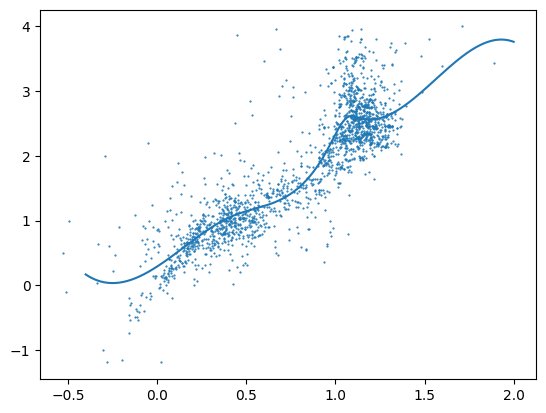

In [19]:
from scipy.interpolate import UnivariateSpline

spline = UnivariateSpline(x, y, k = 3, s = 350)

x_smooth = numpy.linspace(-0.4, 2, 10000)
y_smooth = spline(x_smooth)

plot.scatter(x, y, s = 0.3)
plot.plot(x_smooth, y_smooth)
plot.show()

In [20]:
from LogRMSpline import LogRMSpline

spline = LogRMSpline(spline, x, y)
spline.cap_min(-0.24847484748474846, 0.037222357827663796)
spline.cap_max(1.9305430543054305, 3.7919304730817944)

In [21]:
import pickle

with open('cand_radius_mass_spline.pkl', 'wb') as file:
    pickle.dump(spline, file)

Log Min: -0.75, -0.4643027946875877
Log Max: 1.9306930693069306, 3.7919304730817944
Log Spread: 0.43434015751614913


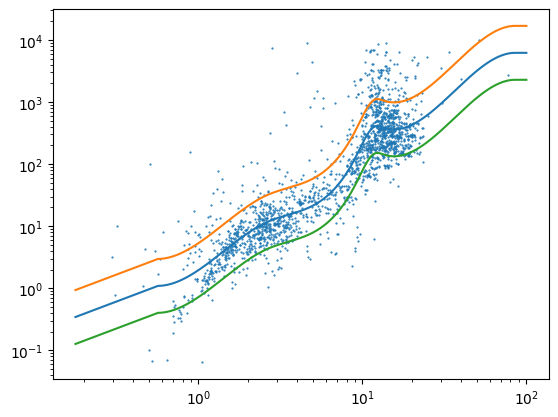

In [24]:
import pickle
import matplotlib.pyplot as plot
import numpy

with open('cand_radius_mass_spline.pkl', 'rb') as file:
    spline = pickle.load(file)

x_smooth = numpy.linspace(-0.75, 2, 10000)
y_smooth = spline(x_smooth)

print(f'Log Min: {x_smooth[numpy.argmin(y_smooth)]}, {numpy.min(y_smooth)}')
print(f'Log Max: {x_smooth[numpy.argmax(y_smooth)]}, {numpy.max(y_smooth)}')
print(f'Log Spread: {spline.spread}')

# y_smooth[x_smooth < x_smooth[numpy.argmin(y_smooth)]] = y_smooth[numpy.argmin(y_smooth)]
# y_smooth[x_smooth > x_smooth[numpy.argmax(y_smooth)]] = y_smooth[numpy.argmax(y_smooth)]

# plot.scatter(x, y, s = 0.3)
# plot.plot(x_smooth, y_smooth)
# plot.plot(numpy.linspace(numpy.min(x_smooth), numpy.max(x_smooth), 10), numpy.linspace(numpy.log10(4130), numpy.log10(4130), 10))

plot.plot(numpy.power(10, x_smooth), numpy.power(10, y_smooth))
plot.plot(numpy.power(10, x_smooth), numpy.power(10, y_smooth + spline.spread))
plot.plot(numpy.power(10, x_smooth), numpy.power(10, y_smooth - spline.spread))
plot.scatter(numpy.power(10, x), numpy.power(10, y), s = 0.3)

# plot.plot(10 ** x_smooth, spline.predict_linear(10 ** x_smooth))
plot.loglog()
plot.show()

In [8]:
print(numpy.mean(x))
print(numpy.std(x))
print(10 ** numpy.mean(x + 2 * numpy.std(x)))

0.7830103462827279
0.4164655986751407
41.29919092242962


In [9]:
from sklearn.mixture import GaussianMixture
radii = data['radius']
radii = radii.to_numpy().reshape(-1, 1)

gmm = GaussianMixture(n_components = 2, random_state = 0)
labels = gmm.fit_predict(radii)

# Separate the two peaks
peak1 = radii[labels == 0]
peak2 = radii[labels == 1]

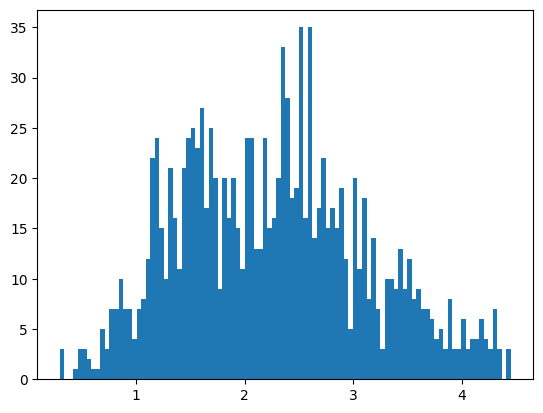

In [10]:
#  = (peak2 - peak2.mean()) / peak2.std()
# ata = data[z < 3]
# rint(max(peak2))
plot.hist(peak2, 100)
plot.show()

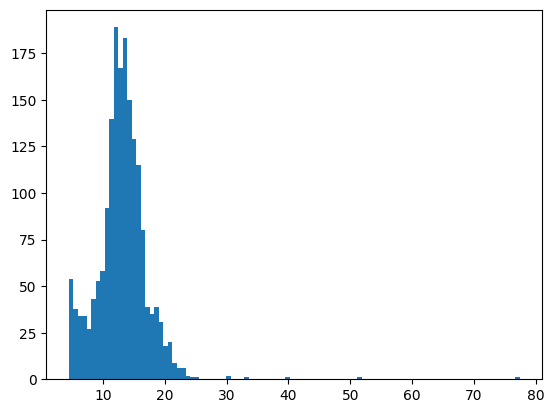

In [11]:
plot.hist(peak1, 100)
plot.show()

25.0


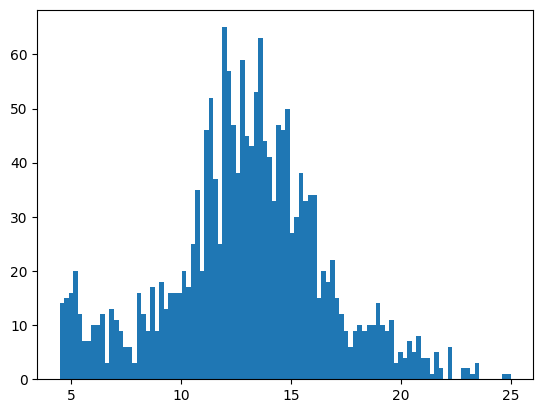

In [12]:
z = (peak1 - peak1.mean()) / peak1.std()
peak1 = peak1[z < 3]
print(max(peak1))
plot.hist(peak1, 100)
plot.show()